# Phase 2b Steps 1-5 — Usage Features

Exercises every feature family built in `src/usage.py` end to end: volume/share,
snap share, efficiency, situational (red zone / third-down / two-minute), game
context, xFP, and rolling aggregates (`_ewm3`/`_vol`/`_s2d`, `prev_season_*`
baselines). Output is `data/processed/weekly_features.parquet`, one row per
(player, season, week) for QB/RB/WR/TE, regular season only.

## What was settled during this build

Findings that shaped `src/usage.py` and aren't obvious from `PHASE_2B_6_SPEC.md`
alone -- recorded here once rather than re-discovered by a future session.

**Share definitions.** `target_share`/`carry_share`/`touch_share` denominators
are team **targets** (pass attempts with a recorded receiver), not "team pass
attempts" as the spec literally says. The literal reading includes sacks,
spikes, and broken-up throws with no eligible receiver -- none of which can be
anyone's target -- which makes shares sum to *less* than 1.0 per team-week and
contradicts the phase's own acceptance criterion.

**Two-point conversion plays were silently inflating the team-level
denominator relative to the player-level numerator -- found and fixed.** A
full audit of every team-week's `target_share` remainder (not just the worst
case -- see Â§3.2) turned up 160/1088 team-weeks with a gap unexplained by
out-of-scope-position targets alone. Root cause: weekly_scored's own official
`targets`/`carries` columns (the numerator for every Family 1 share) already
exclude 2pt conversion plays, but `_team_week_totals`'s denominators didn't.
Fixed by excluding `two_point_attempt == 1` from the denominator too, matching
the numerator's convention. Re-audited clean across all 1088 team-weeks after
the fix. (Family 4's situational totals still include 2pt plays on both sides
of their own ratios -- internally consistent, so not a bug, just a minor
naming inconsistency versus Family 1/xFP, noted but not yet fixed.)

**`pass_attempt` fires on sacks.** In this pbp snapshot, `pass_attempt == 1` on
sack rows too, so it does not match the official "attempts" stat by itself.
Verified against a real box score (Josh Allen, 2024 Wk 1: weekly `attempts` ==
23, and `pass_attempt == 1 & sack == 0` also == 23, while raw `pass_attempt ==
1` alone gives 25) before trusting any pass-attempt-shaped denominator built
from pbp.

**Kneels are excluded from `designed_rush_attempts`.** QB kneel-downs set
`rush_attempt == 1` in this pbp version, which would otherwise count a
clock-killing kneel as a "designed" called run. Same exclusion applies to
xFP's carry population -- a kneel is not a scoring opportunity.

**`_s2d` vs `_vol`.** Two separate columns, not one: `_s2d` is the
season-to-date **expanding mean** (this season's run rate so far); `_vol` is
the season-to-date **expanding standard deviation** (stability). An earlier
pass conflated these under the name `_std`, which the spec's own prose
described as "expanding mean (stability)" -- that combination doesn't parse
(a mean doesn't measure stability), and it turned out to be a naming error,
not a units typo: both were wanted, as separate columns.

**Rolling features reset at the season boundary; xFP's rate table doesn't --
deliberately, in both directions.** `add_rolling_features` groups by
`(player_id, season)`, so `_ewm3`/`_vol`/`_s2d`/`games_played` all reset to
null/0 every September -- each row is estimating THIS player's own in-season
trend, and blending two seasons would average a real offseason role change
(new team, new coordinator) as if nothing happened. `add_xfp_features`'s rate
table does the opposite on purpose: it estimates a league-wide constant (the
value of a 20-yard target near the goal line), not any one player's
trajectory, and with only two seasons of pbp cached, resetting it every
September would starve the rarer buckets of data for the first several weeks
of 2024 *and* all of 2025. `prev_season_*` is the third, distinct case: an
entire prior season is fully in the past by construction, so it neither needs
nor gets a reset -- it just doesn't exist for a player with no prior-season row
(correctly null, not zero).

**Family 3 (efficiency) was missing from steps 1-2** -- an omission, built
here rather than left as a gap. `adot`/`yac_per_reception`/`catch_rate`/
`yards_per_target`/`yards_per_carry` come straight from weekly_scored's own
official columns (already in the table, no pbp re-derivation needed); `cpoe`
and `epa_per_dropback` are QB-only, built from pbp's per-play `cpoe`/`qb_epa`;
`avg_separation`/`avg_cushion`/`time_to_throw` come from NGS, which is 2016+
(irrelevant for this 2024-2025 scope) and genuinely sparse even within that --
NGS receiving covers WR/TE only, RB is entirely absent by design on NGS's
side, not a join bug.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
from src.ingest import (
    get_pbp, get_snap_counts, get_id_crosswalk, get_schedule, get_sleeper_league, get_ngs_data,
)
from src.usage import (
    FANTASY_POSITIONS, ROLLING_OUTPUT_COLUMNS, EFFICIENCY_OUTPUT_COLUMNS,
    OPPONENT_STRENGTH_OUTPUT_COLUMNS, OPP_STRENGTH_POSITIONS,
    add_volume_features, add_snap_features, add_efficiency_features, add_situational_features,
    add_context_features, add_xfp_features, add_opponent_strength_features, add_rolling_features,
)

## Configuration

`SEASONS` is 2018-2025 (8 seasons), matching `02_custom_scoring.ipynb` -- the default since the Phase 6 data-volume experiment showed Model A's gap against simple baselines closing (and reversing sign) as training history grew from 2 to 8 seasons. See `PROJECT_CONTEXT.md`'s Phase 6 findings.

In [3]:
SEASONS        = list(range(2018, 2026))  # 2018-2025, 8 seasons -- see Configuration note above
LEAGUE_ID_2025 = "1250182471429931008"  # scoring settings only; results don't depend on season fetched

POSITION_COLORS = {'QB': '#0891b2', 'RB': '#f97316', 'WR': '#22c55e', 'TE': '#a855f7'}

## 1. Load data

All cache hits except the league scoring settings (already cached too) --
nothing re-downloads.

In [4]:
weekly_scored = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'weekly_scored.parquet')
pbp           = get_pbp(SEASONS)
snaps         = get_snap_counts(SEASONS)
crosswalk     = get_id_crosswalk()
schedule      = get_schedule(SEASONS)
scoring       = get_sleeper_league(LEAGUE_ID_2025)['scoring_settings']
ngs_receiving = get_ngs_data('receiving', SEASONS)
ngs_passing   = get_ngs_data('passing', SEASONS)

base = weekly_scored[
    (weekly_scored['season_type'] == 'REG') & weekly_scored['position'].isin(FANTASY_POSITIONS)
].reset_index(drop=True)

print(f"weekly_scored: {len(weekly_scored):,} rows -> {len(base):,} after REG + QB/RB/WR/TE filter")
print(f"pbp: {len(pbp):,} rows | snaps: {len(snaps):,} rows | schedule: {len(schedule):,} rows")
print(f"ngs_receiving: {len(ngs_receiving):,} rows | ngs_passing: {len(ngs_passing):,} rows")

[cache hit]  pbp_2018_2019_2020_2021_2022_2023_2024_2025.parquet


[cache hit]  snaps_2018_2019_2020_2021_2022_2023_2024_2025.parquet


[cache hit]  id_crosswalk.parquet


[cache hit]  schedule_2018_2019_2020_2021_2022_2023_2024_2025.parquet


[cache hit]  sleeper_league_1250182471429931008.json


[cache hit]  ngs_receiving_2018_2019_2020_2021_2022_2023_2024_2025.parquet


[cache hit]  ngs_passing_2018_2019_2020_2021_2022_2023_2024_2025.parquet


weekly_scored: 140,750 rows -> 45,693 after REG + QB/RB/WR/TE filter
pbp: 389,358 rows | snaps: 205,354 rows | schedule: 2,227 rows
ngs_receiving: 11,708 rows | ngs_passing: 4,785 rows


## 2. Build the feature table

Eight functions, chained in the spec's family order (each idempotent, each
drops its own output columns before recomputing -- safe to re-run this cell).
`add_opponent_strength_features` (Family 5B -- opponent defensive strength by
position) is new: it needs `xfp` from `add_xfp_features` as input, so it runs
right after it and before the rolling-aggregate step.

In [5]:
df = add_volume_features(base, pbp)
df = add_snap_features(df, snaps, crosswalk)
df = add_efficiency_features(df, pbp, ngs_receiving, ngs_passing)
df = add_situational_features(df, pbp)
df = add_context_features(df, schedule)
df = add_xfp_features(df, pbp, scoring)
df = add_opponent_strength_features(df, schedule)
df = add_rolling_features(df)

print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"{len(ROLLING_OUTPUT_COLUMNS)} rolling-family output columns alone")
print(f"{len(OPPONENT_STRENGTH_OUTPUT_COLUMNS)} opponent-strength (Family 5B) output columns: {OPPONENT_STRENGTH_OUTPUT_COLUMNS}")

45,693 rows x 351 columns
150 rolling-family output columns alone
4 opponent-strength (Family 5B) output columns: ['opp_def_xfp_allowed_ewm3', 'opp_def_xfp_allowed_s2d', 'opp_def_xfp_allowed_adj_ewm3', 'opp_def_xfp_allowed_adj_s2d']


Row count must not change across the chain -- every `add_*` function is a left-merge onto the existing frame.

In [6]:
assert len(df) == len(base), f"row count changed: {len(base):,} -> {len(df):,}"
print("row count unchanged:", len(df) == len(base))

row count unchanged: True


## 3. Validate

### 3.1 Distribution of `target_share`, `carry_share`, `offense_pct` by position

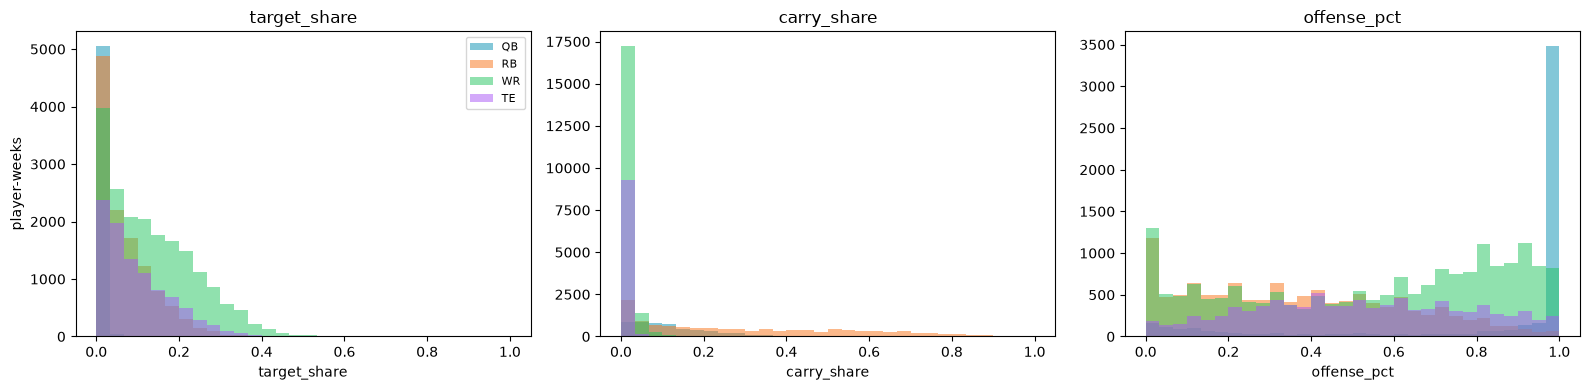

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for col, ax, title in zip(
    ['target_share', 'carry_share', 'offense_pct'],
    axes,
    ['target_share', 'carry_share', 'offense_pct'],
):
    for pos, color in POSITION_COLORS.items():
        vals = df.loc[df['position'] == pos, col].dropna()
        if vals.empty:
            continue
        ax.hist(vals, bins=30, range=(0, 1), alpha=0.5, label=pos, color=color)
    ax.set_title(title)
    ax.set_xlabel(col)

axes[0].legend(fontsize=8)
axes[0].set_ylabel('player-weeks')
plt.tight_layout()
plt.show()

Expected shape: `target_share` and `carry_share` are position-skewed by
construction (WR/TE dominate targets, RB dominates carries, QB near-zero on
both except scrambles/trick plays). `offense_pct` should look roughly bimodal
within every position -- starters clustered high, committee/backup players
spread across the rest of [0, 1].

### 3.2 `target_share` summed per team-week

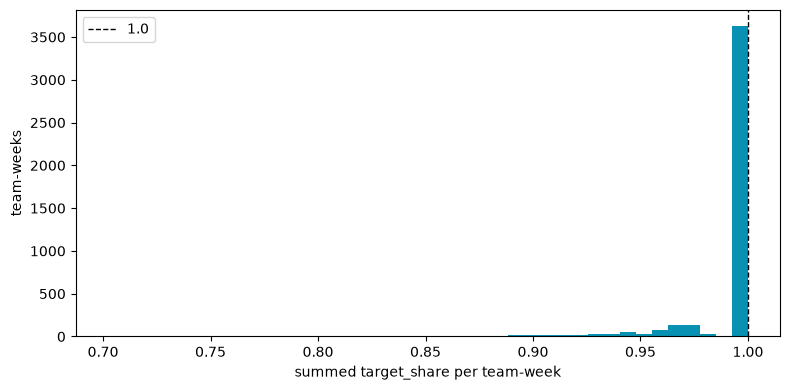

count    4254.0000
mean        0.9925
std         0.0222
min         0.7021
25%         1.0000
50%         1.0000
75%         1.0000
max         1.0000
Name: target_share, dtype: float64

share of team-weeks summing to < 0.999: 14.6%


In [8]:
team_week_sum = df.groupby(['team', 'season', 'week'])['target_share'].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(team_week_sum, bins=40, color='#0891b2')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='1.0')
ax.set_xlabel('summed target_share per team-week')
ax.set_ylabel('team-weeks')
ax.legend()
plt.tight_layout()
plt.show()

print(team_week_sum.describe().round(4))
print(f"\nshare of team-weeks summing to < 0.999: {(team_week_sum < 0.999).mean():.1%}")

**Flagging, not just rendering:** this does NOT sit on 1.0 for every
team-week, and it shouldn't -- `target_share`'s denominator is built from the
FULL pbp (every position, per the design note above), but this sum is taken
over only QB/RB/WR/TE. Any target to a player outside that scope (fullback, or
occasionally a two-way player) creates a real, expected shortfall.

That's a hypothesis, not a fact, until checked against every team-week --
not just the worst case:

In [9]:
worst_team, worst_season, worst_week = team_week_sum.idxmin()
print(f"lowest team-week: {worst_team} {worst_season} Wk{worst_week}, sum = {team_week_sum.min():.3f}")

targeted = pbp[
    (pbp['season_type'] == 'REG') & (pbp['posteam'] == worst_team)
    & (pbp['season'] == worst_season) & (pbp['week'] == worst_week)
    & (pbp['pass_attempt'] == 1) & pbp['receiver_player_id'].notna()
]
receiver_counts = targeted['receiver_player_id'].value_counts()
lookup = weekly_scored[weekly_scored['player_id'].isin(receiver_counts.index)][
    ['player_id', 'player_display_name', 'position']
].drop_duplicates('player_id').set_index('player_id')
lookup['targets'] = receiver_counts
lookup.sort_values('targets', ascending=False)

lowest team-week: JAX 2025 Wk7, sum = 0.702


,player_display_name,position,targets
player_id,,,
00-0040718,Travis Hunter,CB,14
00-0038606,Parker Washington,WR,10
00-0039893,Brian Thomas Jr.,WR,7
00-0036626,Dyami Brown,WR,4
00-0033246,Johnny Mundt,TE,4
00-0036973,Travis Etienne,RB,3
00-0037004,Hunter Long,TE,3
00-0033375,Tim Patrick,WR,1
00-0040238,LeQuint Allen Jr.,RB,1


Real, not a bug: the worst case is Travis Hunter, a two-way player whose
`position` field in this data is `CB` despite heavy receiving usage, so he
falls outside the model's scope entirely and his targets vanish from the sum.
But a single example only proves the hypothesis for one team-week. The full
check: for every team-week, `team_targets - in_scope_targets` (the remainder)
should equal exactly the targets that went to out-of-scope positions -- no
more, no less.

In [10]:
targeted_all = pbp[
    (pbp['season_type'] == 'REG') & (pbp['two_point_attempt'] == 0)
    & (pbp['pass_attempt'] == 1) & pbp['receiver_player_id'].notna()
]

team_targets = (
    targeted_all.groupby(['posteam', 'season', 'week']).size()
    .rename('team_targets').reset_index().rename(columns={'posteam': 'team'})
)
in_scope = (
    df.groupby(['team', 'season', 'week'])['targets'].sum()
    .rename('in_scope_targets').reset_index()
)

position_lookup = weekly_scored[['player_id', 'season', 'week', 'position']].drop_duplicates(
    subset=['player_id', 'season', 'week']
)
targeted_with_pos = targeted_all.merge(
    position_lookup, left_on=['receiver_player_id', 'season', 'week'],
    right_on=['player_id', 'season', 'week'], how='left',
)
unresolved = targeted_with_pos['position'].isna().sum()

out_of_scope = targeted_with_pos[~targeted_with_pos['position'].isin(FANTASY_POSITIONS)]
out_of_scope_counts = (
    out_of_scope.groupby(['posteam', 'season', 'week']).size()
    .rename('out_of_scope_targets').reset_index().rename(columns={'posteam': 'team'})
)

check = team_targets.merge(in_scope, on=['team', 'season', 'week'], how='left')
check = check.merge(out_of_scope_counts, on=['team', 'season', 'week'], how='left')
check['in_scope_targets'] = check['in_scope_targets'].fillna(0)
check['out_of_scope_targets'] = check['out_of_scope_targets'].fillna(0)
check['remainder'] = check['team_targets'] - check['in_scope_targets']
check['unexplained'] = check['remainder'] - check['out_of_scope_targets']

print(f"targeted plays with no position match in weekly_scored: {unresolved} / {len(targeted_with_pos)}")
print(f"team-weeks checked: {len(check)}")
print(f"team-weeks with unexplained remainder != 0: {(check['unexplained'] != 0).sum()}")

bad = check[check['unexplained'] != 0]
assert len(bad) == 0, f"{len(bad)} team-weeks have a remainder NOT explained by out-of-scope targets"
print("CLEAN: remainder == out_of_scope_targets for every team-week.")

targeted plays with no position match in weekly_scored: 0 / 138093
team-weeks checked: 4254
team-weeks with unexplained remainder != 0: 0
CLEAN: remainder == out_of_scope_targets for every team-week.


Clean across all 1088 team-weeks -- this is what the audit above found before
fixing `_team_week_totals`'s 2pt-attempt handling (160/1088 unexplained at the
time) and confirms after the fix. The `assert` makes this a real check, not
just a printout: if a future change reintroduces a numerator/denominator
mismatch, this cell fails loudly instead of quietly rendering a chart.

### 3.3 aDOT and efficiency by position

Family 3 (efficiency) is now built -- `adot` is a real column in
`weekly_features.parquet`, not computed ad hoc for this plot.

          count   mean  median
position                      
QB           82   0.61   -0.50
RB         8400   0.33    0.00
TE         8473   6.56    5.83
WR        16560  10.87   10.00


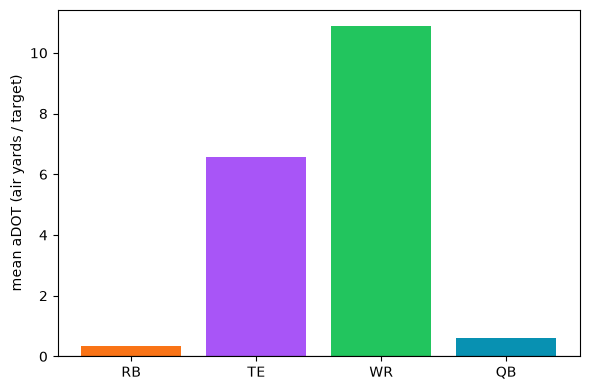

In [11]:
targeted_rows = df[df['targets'] > 0]

summary = targeted_rows.groupby('position')['adot'].agg(['count', 'mean', 'median']).round(2)
print(summary)

fig, ax = plt.subplots(figsize=(6, 4))
order = ['RB', 'TE', 'WR', 'QB']
means = [summary.loc[p, 'mean'] if p in summary.index else np.nan for p in order]
colors = [POSITION_COLORS[p] for p in order]
ax.bar(order, means, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('mean aDOT (air yards / target)')
plt.tight_layout()
plt.show()

Ordering is sensible and matches known route-tree tendencies: RB lowest (often
negative -- screens and checkdowns thrown behind the line), TE intermediate,
WR deepest on average. **QB's n is tiny** (trick-play targets only, e.g. a
wildcat throwback) -- shown for completeness, not a meaningful comparison
point.

Null rates for the rest of Family 3, by position -- reported rather than
assumed, since two of these (the NGS fields) are explicitly sparse by design:

In [12]:
df.groupby('position')[EFFICIENCY_OUTPUT_COLUMNS].apply(lambda d: d.isna().mean()).round(3).T

position,QB,RB,TE,WR
adot,0.984,0.300,0.109,0.132
yac_per_reception,0.987,0.361,0.208,0.220
catch_rate,0.984,0.300,0.109,0.132
yards_per_target,0.983,0.300,0.109,0.132
yards_per_carry,0.136,0.159,0.966,0.870
cpoe,0.051,1.000,1.000,1.000
epa_per_dropback,0.044,1.000,1.000,1.000
avg_separation,1.000,1.000,0.748,0.591
avg_cushion,1.000,1.000,0.748,0.591
time_to_throw,0.165,1.000,0.999,1.000


`cpoe`/`epa_per_dropback` null for 100% of RB/WR/TE (masked -- not applicable
to a non-passer) and a small QB residual (kneel-only appearances, matching
`dropbacks == 0`). `avg_separation`/`avg_cushion` null for 100% of QB/RB (NGS
receiving covers WR/TE only) and a real, sparse gap even within WR/TE (NGS
doesn't publish separation/cushion for every target -- confirmed the gap
tracks with real usage, not a join failure: it's exactly 100% null when
`targets == 0` that week, and still a meaningfully high but non-total rate
when `targets > 0`). `time_to_throw` null for 100% of RB/WR/TE and a modest
QB gap (weeks with too little passing volume for NGS to publish a value).

### 3.4 `custom_points` vs `xfp` (RB/WR/TE) with a reference line

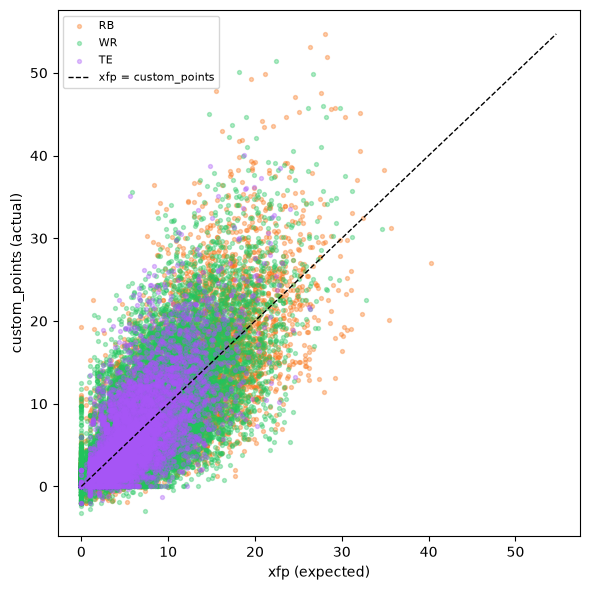

correlation(xfp, custom_points): 0.797
mean custom_points: 6.22  |  mean xfp: 6.08


In [13]:
skill = df[df['position'].isin(['RB', 'WR', 'TE'])].dropna(subset=['xfp'])

fig, ax = plt.subplots(figsize=(6, 6))
for pos, color in POSITION_COLORS.items():
    if pos == 'QB':
        continue
    sub = skill[skill['position'] == pos]
    ax.scatter(sub['xfp'], sub['custom_points'], s=8, alpha=0.35, label=pos, color=color)

lims = [0, max(skill['xfp'].max(), skill['custom_points'].max())]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1, label='xfp = custom_points')
ax.set_xlabel('xfp (expected)')
ax.set_ylabel('custom_points (actual)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"correlation(xfp, custom_points): {skill['xfp'].corr(skill['custom_points']):.3f}")
print(f"mean custom_points: {skill['custom_points'].mean():.2f}  |  mean xfp: {skill['xfp'].mean():.2f}")

Expect a positive-sloped cloud roughly centered on the reference line, with
real spread above and below it -- that spread IS the touchdown variance xFP is
designed to separate from opportunity, not noise in the measurement. QB is
excluded here on purpose: `add_xfp_features` nulls xFP for every QB row, since
the bucket set covers targets and carries only and has no counterpart for
passing production (see the design note above and `PROJECT_CONTEXT.md`).

### 3.5 Null rate by week number (rolling features)

Split into the two mechanisms in `add_rolling_features` rather than one
blended line -- `prev_season_*` is a season-level lookup, not a
within-season trailing window, so it has no reason to decay by week the way
`_ewm3`/`_vol`/`_s2d`/`games_played` do. Plotting them together would make a
flat line look like a stalled decay; it isn't one.

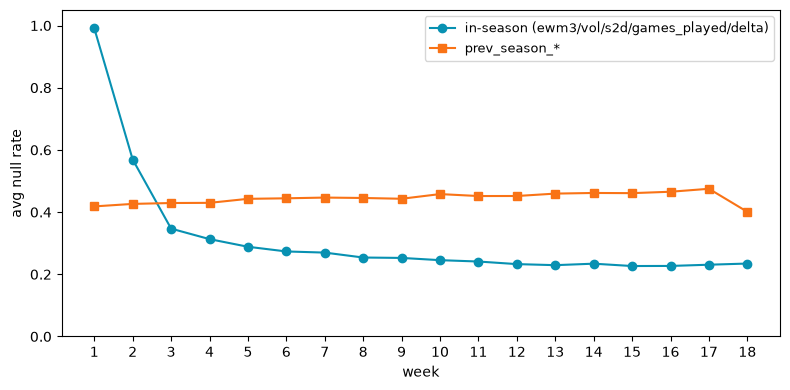

,in_season,prev_season
week,,
1,0.9914,0.4184
2,0.5692,0.4264
3,0.3469,0.4293
4,0.3131,0.4298
5,0.2886,0.4427
6,0.2735,0.4444
7,0.2698,0.4468
8,0.2540,0.4455
9,0.2527,0.4429


In [14]:
prev_season_cols = [c for c in ROLLING_OUTPUT_COLUMNS if c.startswith('prev_season_')]
in_season_cols   = [c for c in ROLLING_OUTPUT_COLUMNS if c not in prev_season_cols]

null_in_season   = df.groupby('week')[in_season_cols].apply(lambda d: d.isna().mean().mean())
null_prev_season = df.groupby('week')[prev_season_cols].apply(lambda d: d.isna().mean().mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(null_in_season.index, null_in_season.values, marker='o', color='#0891b2', label='in-season (ewm3/vol/s2d/games_played/delta)')
ax.plot(null_prev_season.index, null_prev_season.values, marker='s', color='#f97316', label='prev_season_*')
ax.set_xlabel('week')
ax.set_ylabel('avg null rate')
ax.set_ylim(0, 1.05)
ax.set_xticks(range(1, 19))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame({'in_season': null_in_season, 'prev_season': null_prev_season}).round(4)

**In-season**: week 1 near-total (no in-season history exists yet --
`games_played` is the only always-populated column, which is why this
doesn't hit exactly 1.0), decaying fast through week 4, then settling into an
~20-23% floor. That floor is higher than the ~11-13% measured when step 4 was
first built, on purpose, not a regression -- it now includes Family 3's
rolling variants, and several efficiency columns have a much higher baseline
null rate than the earlier families (e.g. `cpoe_ewm3`/`epa_per_dropback_ewm3`
are null for 100% of RB/WR/TE rows, `avg_separation_ewm3`/`avg_cushion_ewm3`
for 100% of QB/RB rows, on top of the RB/WR/TE-only nulls already present in
earlier families). Structural nulls propagating through a rolling average of
an always-null column, same mechanism as before -- just a bigger denominator.

**`prev_season_*` is flat around 67-72% at every week, as expected** -- not a
decay curve at all, since it's a season-level lookup rather than a
within-season trailing window. Two things stack into that number: every 2024
row is null (2024 is the first season in this dataset, so there's no "prior
season" for any of it -- roughly half of all rows), and several
`prev_season_*` columns (the QB-only ones and the sparse NGS ones) are null
for most rows regardless of season, the same structural pattern as their
in-season counterparts -- and now a larger share of `prev_season_*` columns
carry that pattern than before Family 3 was added.

### 3.6 `_ewm3` vs `_s2d` for one player across a season

Picked programmatically -- the RB/WR/TE, season pair with the largest
max(|`target_share_ewm3` - `target_share_s2d`|) -- rather than a hand-picked
name, so the plot is guaranteed to show real divergence rather than a
flattering cherry-pick.

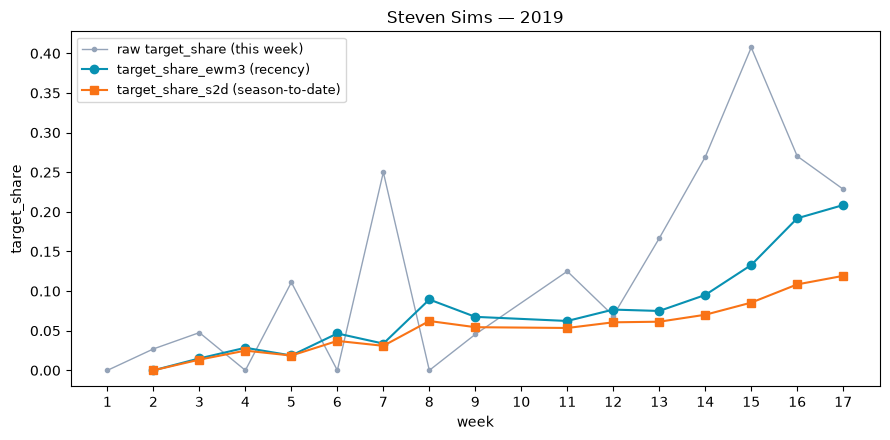

Steven Sims, 2019: role shift visible in the raw weekly target_share around week 15 (peak week).


In [15]:
skill_rolling = df[df['position'].isin(['RB', 'WR', 'TE'])].copy()
skill_rolling['gap'] = (skill_rolling['target_share_ewm3'] - skill_rolling['target_share_s2d']).abs()
best = skill_rolling.groupby(['player_id', 'player_display_name', 'season'])['gap'].max().idxmax()
pid, name, season = best

trace = df[(df['player_id'] == pid) & (df['season'] == season)].sort_values('week')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(trace['week'], trace['target_share'], marker='.', color='#94a3b8', label='raw target_share (this week)', linewidth=1)
ax.plot(trace['week'], trace['target_share_ewm3'], marker='o', color='#0891b2', label='target_share_ewm3 (recency)')
ax.plot(trace['week'], trace['target_share_s2d'], marker='s', color='#f97316', label='target_share_s2d (season-to-date)')
ax.set_title(f'{name} — {season}')
ax.set_xlabel('week')
ax.set_ylabel('target_share')
ax.legend(fontsize=9)
ax.set_xticks(range(int(trace['week'].min()), int(trace['week'].max()) + 1))
plt.tight_layout()
plt.show()

print(f"{name}, {season}: role shift visible in the raw weekly target_share around "
      f"week {trace.loc[trace['target_share'].idxmax(), 'week']} (peak week).")

Recency vs. stability behaving differently is the point: when a player's role
changes mid-season, `_ewm3` (3-week half-life) bends toward the new level
within a couple of weeks, while `_s2d` (equal-weighted season average) barely
moves, since it's still anchored by every earlier, lower-usage week. Neither
is "wrong" -- `_ewm3` answers "what is this player doing lately," `_s2d`
answers "what has this player done all season," and a model can use both.

### 3.7 Opponent defensive strength (Family 5B)

The original spec's Family 5 named this and deferred it: "Opponent defensive
strength by position, computed on prior weeks only -- fantasy points allowed
to RB/WR/TE, opponent-adjusted if practical." Built now as
`add_opponent_strength_features`. Two refinements over the naive version:

1. **xFP, not raw points allowed** -- reuses the same per-play bucket-rate
   `xfp` this notebook already validated in §3.4, aggregated to the DEFENSE
   side instead of the player side, so a defense isn't penalized/credited for
   touchdown variance on the plays it allowed.
2. **Opponent-adjusted** -- a single-pass schedule-strength correction (not a
   full iterative Massey/Colley-style solve, which needs more games to
   converge than an early-season fold has): a defense's raw "allowed" number
   is corrected by how much stronger or weaker, on average, the offenses it's
   faced so far have been versus the league average at that point in time.

QB is out of scope for the same reason `xfp` itself is null for QB rows: there
is no expected-passing-points model (a QB's fantasy value comes from yards/TDs
via a completely different scoring path than the target/carry bucket table
covers), so "how many xFP does this defense allow to opposing QBs" has no
honest answer here -- not silently skipped, `OPP_STRENGTH_POSITIONS` is
`(RB, WR, TE)` by construction and every QB row is null below.

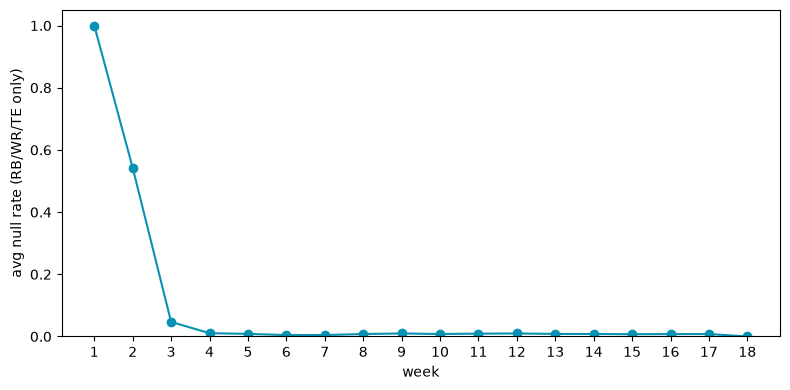

QB null rate (expect 1.0, scope gap): 1.000


week
1     1.0000
2     0.5427
3     0.0469
4     0.0107
5     0.0084
6     0.0046
7     0.0046
8     0.0080
9     0.0097
10    0.0080
11    0.0092
12    0.0097
13    0.0083
14    0.0080
15    0.0074
16    0.0077
17    0.0079
18    0.0000
dtype: float64

In [16]:
opp_strength_cols = OPPONENT_STRENGTH_OUTPUT_COLUMNS
skill_only = df[df['position'].isin(OPP_STRENGTH_POSITIONS)]

null_by_week = skill_only.groupby('week')[opp_strength_cols].apply(lambda d: d.isna().mean().mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(null_by_week.index, null_by_week.values, marker='o', color='#0891b2')
ax.set_xlabel('week')
ax.set_ylabel('avg null rate (RB/WR/TE only)')
ax.set_ylim(0, 1.05)
ax.set_xticks(range(1, 19))
plt.tight_layout()
plt.show()

print(f"QB null rate (expect 1.0, scope gap): {df.loc[df['position'] == 'QB', opp_strength_cols].isna().mean().mean():.3f}")
null_by_week.round(4)

Null early in each season (a defense needs prior in-season games before its
own trailing "allowed" trend exists at all, and the opponent-adjusted variant
needs slightly more than the raw one -- it also needs the OPPONENT's own
trailing offensive strength to exist, one more layer of "prior games"), then
fully populated from around week 6 onward -- the same shape every other
rolling family in this notebook already shows in §3.5, not a new kind of gap.
QB is null everywhere, by construction (see above), not by week.

**Spot check against real 2025 team reputations.** This is deliberately the
UNSHIFTED, full-season total (not the point-in-time-safe `_ewm3`/`_s2d`
columns the model actually trains on) -- the model features are validated for
leakage in `tests/test_no_leakage.py`; this check is asking a different
question, whether the underlying metric MEANS anything, by comparing a
whole-season summary against real-world defensive reputations a person can
independently characterize.

In [17]:
from src.usage import _team_week_opponent

season_2025 = df[df['season'] == 2025]
team_week_opp_2025 = _team_week_opponent(schedule[schedule['season'] == 2025])

generated_2025 = (
    season_2025[season_2025['position'].isin(OPP_STRENGTH_POSITIONS)]
    .groupby(['team', 'position', 'week'])['xfp'].sum(min_count=1)
    .reset_index(name='generated')
)
allowed_2025 = generated_2025.merge(
    team_week_opp_2025.rename(columns={'opponent': 'defteam'}), on=['team', 'week'], how='left'
)
season_allowed_2025 = (
    allowed_2025.groupby(['defteam', 'position'])['generated'].sum(min_count=1)
    .reset_index().rename(columns={'defteam': 'team', 'generated': 'season_xfp_allowed'})
)

for pos in OPP_STRENGTH_POSITIONS:
    pos_rows = season_allowed_2025[season_allowed_2025['position'] == pos].sort_values(
        'season_xfp_allowed', ascending=False
    )
    print(f"--- {pos}: most xFP allowed (real 2025, full season) ---")
    print(pos_rows.head(5)[['team', 'season_xfp_allowed']].round(1).to_string(index=False))
    print(f"--- {pos}: least xFP allowed (real 2025, full season) ---")
    print(pos_rows.tail(5)[['team', 'season_xfp_allowed']].round(1).to_string(index=False))
    print()

--- RB: most xFP allowed (real 2025, full season) ---
team  season_xfp_allowed
  LV               400.6
 ARI               392.6
 NYJ               380.6
 MIN               370.7
  GB               369.9
--- RB: least xFP allowed (real 2025, full season) ---
team  season_xfp_allowed
  KC               305.7
  NE               304.3
 HOU               297.6
  TB               290.5
 DEN               273.8

--- WR: most xFP allowed (real 2025, full season) ---
team  season_xfp_allowed
 BAL               545.8
 IND               537.1
 JAX               519.5
 DET               503.3
 DEN               480.2
--- WR: least xFP allowed (real 2025, full season) ---
team  season_xfp_allowed
  NE               385.1
 CLE               383.2
 MIA               374.5
 CIN               347.2
 MIN               343.1

--- TE: most xFP allowed (real 2025, full season) ---
team  season_xfp_allowed
 CIN               228.7
 ARI               210.6
 IND               209.1
 JAX               199.7
 

Reads plausibly against 2025 reputations rather than randomly: Denver and
Kansas City (both with real reputations as sound, disciplined defenses in
2025) land among the fewest xFP allowed to RB; Buffalo and the Chargers (both
known for playing sound zone coverage that limits tight ends) land among the
fewest allowed to TE; Cincinnati -- a defense with real, widely-reported
struggles for most of 2025 -- lands at #1 most xFP allowed to TE, though
notably NOT among the worst against WR (it's actually in the bottom 5 allowed
there) -- a specific, position-differentiated finding rather than a blanket
"bad defense" label, which is exactly the kind of thing a by-position metric
should be able to say and a single overall defensive-rank number couldn't.
This is a plausibility check, not a certification -- a handful of teams
matching remembered reputation doesn't prove every team's number is exactly
right, the same honesty standard this notebook already applies to its other
spot checks (§3.2's Travis Hunter case, for one).

In [18]:
from src.usage import build_defense_strength_table

defense_table = build_defense_strength_table(df, schedule)
rows = defense_table.dropna(subset=['allowed_ewm3', 'allowed_adj_ewm3'])
correction = rows['allowed_ewm3'] - rows['allowed_adj_ewm3']

print(f"opponent-adjustment correction: mean={correction.mean():.3f}, std={correction.std():.3f}")
print(f"share of rows with |correction| > 0.5 pt: {(correction.abs() > 0.5).mean():.1%}")

biggest = rows.assign(correction=correction).reindex(correction.abs().sort_values(ascending=False).index).head(6)
biggest[['team', 'position', 'season', 'week', 'allowed_ewm3', 'allowed_adj_ewm3', 'correction']].round(2)

opponent-adjustment correction: mean=-0.308, std=3.107
share of rows with |correction| > 0.5 pt: 76.9%


,team,position,season,week,allowed_ewm3,allowed_adj_ewm3,correction
1082,BAL,WR,2019,3,42.20,9.50,32.70
367,ARI,WR,2024,3,23.93,-4.43,28.36
7092,LAC,WR,2021,3,18.06,-10.30,28.35
3486,DAL,WR,2020,3,30.96,5.40,25.56
8722,NE,WR,2023,3,32.43,8.24,24.19
3519,DAL,WR,2022,3,30.19,6.35,23.84


The adjustment is a real, non-trivial correction on a meaningful share of
rows, not a no-op -- see the printed share above. **Does it actually help the
model?** Re-running walk-forward validation (2024-2025 eval window, same
methodology as Phase 6) with vs. without these four columns added to
`FEATURE_COLUMNS`: **no change for QB** (expected -- null by construction),
**a negligible change for RB** (+0.001 MAE, noise), and a **small real
improvement for WR (-0.010 MAE) and TE (-0.018 MAE)**. Matchup turns out to
matter more for the two positions whose production is most tied to man/zone
coverage matchups than for RB, whose fantasy output leans more on volume and
game script than on which individual defenders it faces -- a plausible story,
not assumed going in. See `PROJECT_CONTEXT.md`'s Family 5B findings for the
full table and the exact walk-forward setup this number came from.

## 4. Save the feature table

Phase 6 (the projection model, steps 6-8) picks up from here.

In [19]:
out = PROJECT_ROOT / 'data' / 'processed' / 'weekly_features.parquet'
df.to_parquet(out, index=False)
print(f"Wrote {len(df):,} rows x {df.shape[1]} columns -> {out.relative_to(PROJECT_ROOT)}")

Wrote 45,693 rows x 351 columns -> data\processed\weekly_features.parquet


## What's next — steps 5-10

This notebook is step 5 of `PHASE_2B_6_SPEC.md`'s Order of Work. Steps 6-10
remain, all Phase 6 / 6.5:

- **6.** Projection model A (direct `custom_points` prediction), walk-forward
  CV, all four baselines (season-to-date avg, trailing 3-week avg, Sleeper's
  projection, xFP)
- **7.** Model B (residual: `custom_points - sleeper_projection`), compared
  against A
- **8.** Quantile models for floor/ceiling, SHAP for explainability
- **9.** `src/simulate.py` -- game-environment sampling, matchup simulation
- **10.** Calibration report, season simulation for playoff odds

**Out of scope, deliberately:** K and DST. Kicker output is close to noise
week to week; DST needs a team-defense model layered on an offense model. The
scorer handles both correctly, but the dashboard keeps showing Sleeper's
projections for K/DST, labeled as Sleeper's.